# Part 4 — Open Question

**Research question:** *Does a correlation exist between sentiment (negativity / anger) and the structural importance of a node in the Bluesky political reply network?*

This notebook tests the hypothesis end-to-end:

1. **Node-level sentiment aggregation** — collapse edge sentiment onto nodes; directed in/out split
2. **Centrality–sentiment correlation** — Spearman ρ between node sentiment and each of the five centrality measures
3. **Intra- vs. inter-community sentiment** — test whether community boundaries are also sentiment boundaries (echo-chamber test)
4. **Affective homophily** — assortativity of node sentiment; per-community breakdown
5. **Outlier nodes** — accounts structurally inside a community but affectively deviant

**Inputs:**
- `private/dataset_part3_with_communities.gexf` — undirected GCC with centralities + Leiden community labels
- `private/dataset_roberta_final.gexf` — original directed graph with `sentiment_roberta` on edges
- `private/communities_leiden.json` — node → community id mapping

## 0. Setup

In [1]:
import json
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RNG_SEED = 42

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ---------- load graphs ----------
# Undirected GCC with centralities and community labels (from Part 3)
G = nx.read_gexf('private/dataset_part3_with_communities.gexf')

# Original directed graph (needed for in/out sentiment split)
G_dir = nx.read_gexf('private/dataset_roberta_final.gexf')

# Community assignments
with open('private/communities_leiden.json') as f:
    node2com = json.load(f)

print(f'Undirected GCC  — nodes: {G.number_of_nodes():,}  edges: {G.number_of_edges():,}')
print(f'Directed graph  — nodes: {G_dir.number_of_nodes():,}  edges: {G_dir.number_of_edges():,}')
print(f'Communities     — {len(set(node2com.values()))} distinct labels')

# Quick check: what node attributes are available?
sample_node = list(G.nodes(data=True))[0]
print('\nNode attribute keys:', list(sample_node[1].keys()))
sample_edge = list(G.edges(data=True))[0]
print('Edge attribute keys:', list(sample_edge[2].keys()))

Undirected GCC  — nodes: 10,595  edges: 13,263
Directed graph  — nodes: 10,855  edges: 14,011
Communities     — 60 distinct labels

Node attribute keys: ['centrality_degree', 'centrality_closeness', 'centrality_betweenness', 'centrality_eigenvector', 'centrality_pagerank', 'community', 'label']
Edge attribute keys: ['sentiment_roberta', 'interaction_weight', 'id']


## 1. Node-level sentiment aggregation

We derive three sentiment scalars for each node:

| Scalar | Definition |
|---|---|
| `sent_undirected` | mean `sentiment_roberta` of all incident edges in *G* |
| `sent_in` | mean sentiment of edges *pointing to* the node in *G_dir* (how others talk to/about it) |
| `sent_out` | mean sentiment of edges *from* the node in *G_dir* (how it talks to others) |

A node where `sent_in ≪ sent_out` is a **target** (attracts hostility).  
A node where `sent_out ≪ sent_in` is an **instigator** (generates hostility).

In [2]:
# --- 1a. Undirected node sentiment ---
node_sent_undirected = {}
for node in G.nodes():
    scores = [d.get('sentiment_roberta', np.nan)
              for _, _, d in G.edges(node, data=True)]
    scores = [s for s in scores if not np.isnan(s)]
    node_sent_undirected[node] = np.mean(scores) if scores else np.nan

# --- 1b. Directed in/out sentiment ---
node_sent_in  = defaultdict(list)
node_sent_out = defaultdict(list)

for u, v, d in G_dir.edges(data=True):
    s = d.get('sentiment_roberta', np.nan)
    if np.isnan(s):
        continue
    # u -> v means u replied to v's post
    node_sent_out[u].append(s)   # u is speaking
    node_sent_in[v].append(s)    # v is being spoken to

node_sent_in  = {n: np.mean(v) for n, v in node_sent_in.items()}
node_sent_out = {n: np.mean(v) for n, v in node_sent_out.items()}

# --- Build a summary DataFrame ---
nodes_in_gcc = list(G.nodes())
df = pd.DataFrame(index=nodes_in_gcc)

df['sent_undirected'] = pd.Series(node_sent_undirected)
df['sent_in']         = pd.Series(node_sent_in)
df['sent_out']        = pd.Series(node_sent_out)

# Raw (unnormalised) topological degree -- needed to judge how many comments
# back up each node's sentiment estimate (centrality_degree is normalised by N-1)
df['deg_raw'] = pd.Series(dict(G.degree()))

# Pull centrality measures from node attributes
centrality_keys = ['degree', 'betweenness', 'closeness', 'eigenvector', 'pagerank']
# Try to read from node attributes (adjust key names if your GEXF uses different names)
for key in centrality_keys:
    # df[key] = pd.Series({n: G.nodes[n].get(key, np.nan) for n in nodes_in_gcc})
    df[key] = pd.Series({n: G.nodes[n].get(f'centrality_{key}', np.nan) for n in nodes_in_gcc})


# Community label
df['community'] = pd.Series(node2com)

df.dropna(subset=['sent_undirected'], inplace=True)
print(f'Nodes with valid sentiment: {len(df):,}')
print(df[['sent_undirected', 'sent_in', 'sent_out', 'deg_raw'] + centrality_keys].describe().round(4))

Nodes with valid sentiment: 10,595
       sent_undirected    sent_in    sent_out     deg_raw      degree  \
count       10595.0000  1955.0000  10438.0000  10595.0000  10595.0000   
mean           -0.3869    -0.3269     -0.3940      2.5036      0.0002   
std             0.4887     0.4811      0.5010     14.8887      0.0014   
min            -0.9566    -0.9504     -0.9566      1.0000      0.0001   
25%            -0.7963    -0.7286     -0.8139      1.0000      0.0001   
50%            -0.5104    -0.4270     -0.5402      1.0000      0.0001   
75%            -0.0933    -0.0245     -0.0848      2.0000      0.0002   
max             0.9880     0.9848      0.9880    916.0000      0.0865   

       betweenness   closeness  eigenvector    pagerank  
count   10595.0000  10595.0000   10595.0000  10595.0000  
mean        0.0004      0.2031       0.0025      0.0001  
std         0.0038      0.0277       0.0094      0.0005  
min         0.0000      0.0751       0.0000      0.0000  
25%         0.000

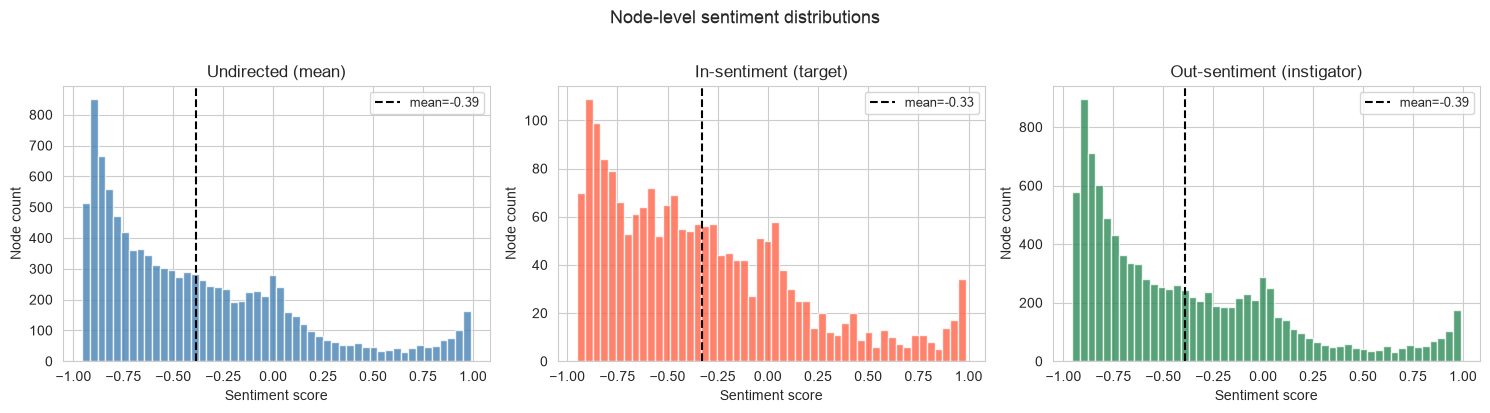

In [3]:
# --- Visualise the three sentiment distributions ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

cols   = ['sent_undirected', 'sent_in', 'sent_out']
labels = ['Undirected (mean)', 'In-sentiment (target)', 'Out-sentiment (instigator)']
colors = ['steelblue', 'tomato', 'seagreen']

for ax, col, label, color in zip(axes, cols, labels, colors):
    data = df[col].dropna()
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'mean={data.mean():.2f}')
    ax.set_title(label)
    ax.set_xlabel('Sentiment score')
    ax.set_ylabel('Node count')
    ax.legend(fontsize=9)

plt.suptitle('Node-level sentiment distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p4_fig1_sentiment_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 1b. Node reliability: degree as a noise filter

`sent_undirected` is a mean over a node's incident edges. For a degree-1 node that "mean" is the score of a **single comment** -- noise, not a stable trait. Since edges almost never aggregate more than one comment (97.2% have `weight = 1`, see Part 2), degree is a good proxy for how many independent observations back up a node's score.

Before trusting node-level correlations we check how the reliability of `sent_undirected` changes with degree, and use that to pick a minimum-degree threshold `K` for a "robust" subset.

               n   mean    std
deg_bucket                    
1           7597 -0.383  0.533
2           1741 -0.399  0.393
3            600 -0.413  0.313
4            236 -0.363  0.291
5-9          274 -0.376  0.271
10+          147 -0.387  0.206


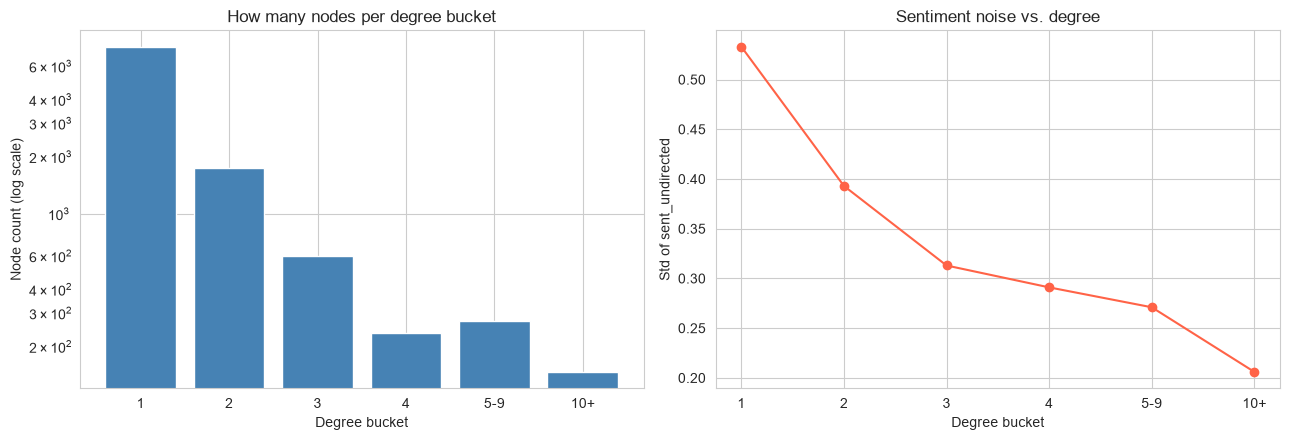


Robust subset (deg_raw >= 5): 421 nodes (4.0% of 10,595)


In [4]:
# --- Reliability of sent_undirected as a function of degree ---
bins = [1, 2, 3, 4, 5, 10, np.inf]
bucket_labels = ['1', '2', '3', '4', '5-9', '10+']
df['deg_bucket'] = pd.cut(df['deg_raw'], bins=bins, labels=bucket_labels, right=False)

reliability = df.groupby('deg_bucket', observed=True)['sent_undirected'].agg(
    n='count', mean='mean', std='std'
).round(3)
print(reliability)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(reliability.index.astype(str), reliability['n'], color='steelblue')
axes[0].set_yscale('log')
axes[0].set_xlabel('Degree bucket')
axes[0].set_ylabel('Node count (log scale)')
axes[0].set_title('How many nodes per degree bucket')

axes[1].plot(reliability.index.astype(str), reliability['std'], marker='o', color='tomato')
axes[1].set_xlabel('Degree bucket')
axes[1].set_ylabel('Std of sent_undirected')
axes[1].set_title('Sentiment noise vs. degree')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p4_fig1b_degree_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

K = 5  # minimum degree for the "robust" subset -- see std plateau above
df_robust = df[df['deg_raw'] >= K].copy()
print(f'\nRobust subset (deg_raw >= {K}): {len(df_robust):,} nodes '
      f'({len(df_robust) / len(df):.1%} of {len(df):,})')

### 1c. Target vs. instigator classification

A node is a **target** if `sent_in − sent_out < −0.1` (receives much more hostile replies than it sends).  
A node is an **instigator** if `sent_out − sent_in < −0.1` (sends much more hostile replies than it receives).  
Otherwise it is **neutral**.

In [5]:
THRESHOLD = 0.1

df_dir = df.dropna(subset=['sent_in', 'sent_out']).copy()
df_dir['delta'] = df_dir['sent_in'] - df_dir['sent_out']

df_dir['role'] = 'neutral'
df_dir.loc[df_dir['delta'] < -THRESHOLD, 'role'] = 'target'
df_dir.loc[df_dir['delta'] >  THRESHOLD, 'role'] = 'instigator'

print(df_dir['role'].value_counts())
print()

# Top 10 targets by in-degree (most replied-to AND most negative incoming)
top_targets = (
    df_dir[df_dir['role'] == 'target']
    .sort_values('degree', ascending=False)
    .head(10)[['degree', 'sent_in', 'sent_out', 'delta', 'betweenness', 'pagerank']]
)
print('Top targets (high degree + hostile incoming):')
print(top_targets.round(3))

print()
top_instigators = (
    df_dir[df_dir['role'] == 'instigator']
    .sort_values('degree', ascending=False)
    .head(10)[['degree', 'sent_in', 'sent_out', 'delta', 'betweenness', 'pagerank']]
)
print('Top instigators (high degree + hostile outgoing):')
print(top_instigators.round(3))

# --- Same breakdown restricted to the robust subset (deg_raw >= K) ---
df_dir_robust = df_dir[df_dir['deg_raw'] >= K]
print(f'\nRole counts, robust subset only (deg_raw >= {K}, n={len(df_dir_robust):,}):')
print(df_dir_robust['role'].value_counts())

role
instigator    800
target        652
neutral       346
Name: count, dtype: int64

Top targets (high degree + hostile incoming):
                degree  sent_in  sent_out  delta  betweenness  pagerank
cortneymckee     0.045   -0.360    -0.050 -0.310        0.121     0.015
jonbandit        0.023   -0.479    -0.246 -0.233        0.048     0.008
nancabell        0.017   -0.549    -0.148 -0.401        0.037     0.006
barrelbucket     0.011   -0.323     0.122 -0.445        0.024     0.004
melindameyer     0.010   -0.516     0.220 -0.736        0.020     0.004
sunnyday52100    0.010   -0.483     0.028 -0.511        0.015     0.003
hairball-redux   0.010   -0.379     0.115 -0.494        0.029     0.003
helldude         0.009   -0.480     0.026 -0.506        0.030     0.004
stewardship      0.009   -0.474     0.314 -0.788        0.015     0.003
snelsonus        0.004   -0.022     0.300 -0.322        0.006     0.002

Top instigators (high degree + hostile outgoing):
                  degree 

**Reading:** hostility is pervasive (mean node sentiment −0.387) but not symmetric across roles: instigators outnumber targets (800 vs. 652, with 346 neutral). The same split holds almost unchanged in the robust subset (`deg_raw >= 5`, n=267): 125 instigators vs. 100 targets vs. 42 neutral — so the asymmetry is not an artefact of leaf noise, it is a structural feature of how these accounts behave.

## 2. Centrality–sentiment correlation

We compute Spearman ρ between `sent_undirected` and each centrality measure.  
We also test the directed hypotheses:

- `sent_in` vs. degree/betweenness (do structural hubs attract more hostility?)
- `sent_out` vs. degree/betweenness (do structural hubs also generate more hostility?)

Since most nodes are leaves whose sentiment is a single comment (§1d), every correlation below is computed twice: on **all** nodes and on the **robust subset** (`deg_raw >= K`). If the two agree, the null result is real; if the robust subset diverges, leaf noise was masking a signal.

In [6]:
sentiment_cols  = ['sent_undirected', 'sent_in', 'sent_out']
results = []

for subset_label, source_df in [('all', df), (f'robust (deg>={K})', df_robust)]:
    for sent_col in sentiment_cols:
        for cent_col in centrality_keys:
            sub = source_df[[sent_col, cent_col]].dropna()
            if len(sub) < 30:
                continue
            rho, pval = stats.spearmanr(sub[sent_col], sub[cent_col])
            results.append({
                'subset': subset_label,
                'sentiment': sent_col,
                'centrality': cent_col,
                'spearman_rho': round(rho, 4),
                'p_value': pval,
                'n': len(sub),
                'significant': pval < 0.05
            })

corr_df = pd.DataFrame(results)
print(corr_df.to_string(index=False))

# Side-by-side comparison for the undirected sentiment score
pivot_compare = corr_df[corr_df['sentiment'] == 'sent_undirected'].pivot(
    index='centrality', columns='subset', values='spearman_rho'
)
print('\nAll nodes vs. robust subset (rho, sent_undirected):')
print(pivot_compare.round(4))

         subset       sentiment  centrality  spearman_rho      p_value     n  significant
            all sent_undirected      degree        0.0828 1.370512e-17 10595         True
            all sent_undirected betweenness        0.0752 9.264010e-15 10595         True
            all sent_undirected   closeness       -0.0828 1.364705e-17 10595         True
            all sent_undirected eigenvector       -0.0764 3.396779e-15 10595         True
            all sent_undirected    pagerank        0.1138 7.146408e-32 10595         True
            all         sent_in      degree        0.0285 2.080731e-01  1955        False
            all         sent_in betweenness        0.0040 8.594582e-01  1955        False
            all         sent_in   closeness       -0.0196 3.864908e-01  1955        False
            all         sent_in eigenvector       -0.0105 6.439445e-01  1955        False
            all         sent_in    pagerank        0.0404 7.414291e-02  1955        False
          

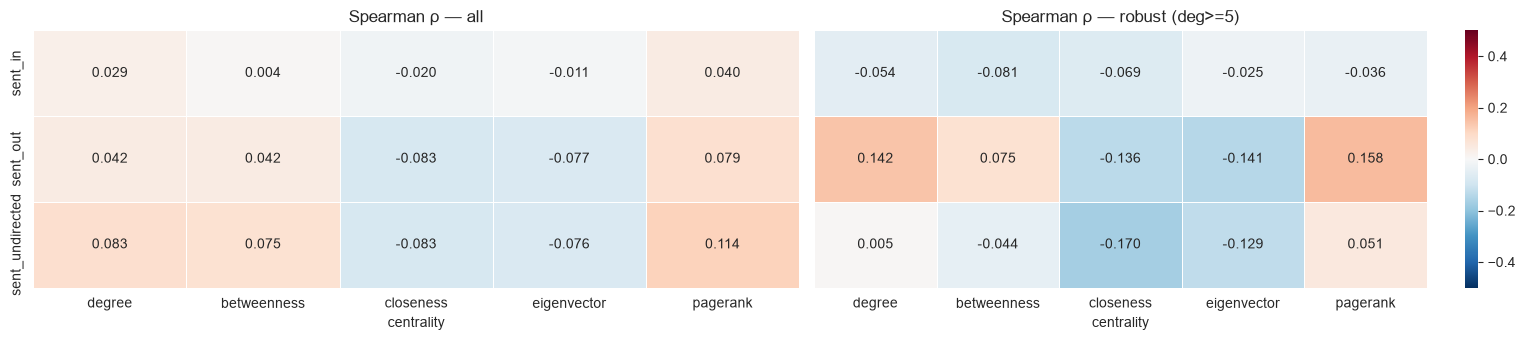

In [7]:
# --- Heatmap of Spearman rho: all nodes vs. robust subset ---
fig, axes = plt.subplots(1, 2, figsize=(16, 3.5), sharey=True)

for ax, subset_label in zip(axes, ['all', f'robust (deg>={K})']):
    pivot = (corr_df[corr_df['subset'] == subset_label]
             .pivot(index='sentiment', columns='centrality', values='spearman_rho'))
    pivot = pivot[centrality_keys]
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                vmin=-0.5, vmax=0.5, linewidths=0.5, ax=ax, cbar=ax is axes[-1])
    ax.set_title(f'Spearman ρ — {subset_label}', fontsize=12)
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p4_fig2_spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

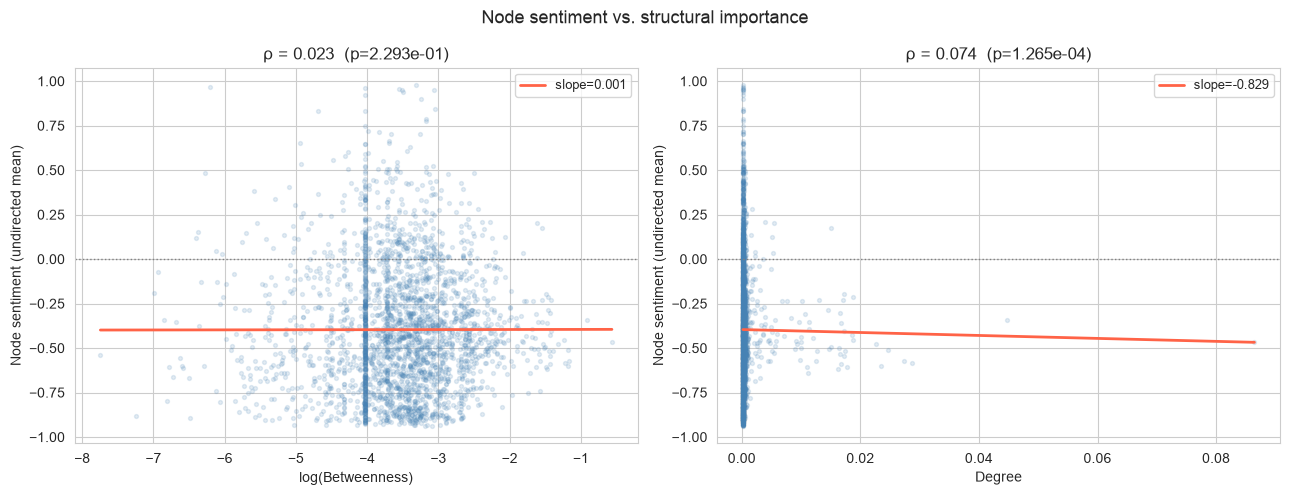

In [8]:
# --- Scatter: sent_undirected vs log(betweenness) ---
# Use log scale because betweenness is extremely right-skewed
sub = df[['sent_undirected', 'betweenness', 'degree']].dropna()
sub = sub[sub['betweenness'] > 0]  # log requires > 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cent_col, label in zip(axes,
                                ['betweenness', 'degree'],
                                ['log(Betweenness)', 'Degree']):
    x = np.log10(sub[cent_col]) if cent_col == 'betweenness' else sub[cent_col]
    y = sub['sent_undirected']
    ax.scatter(x, y, alpha=0.15, s=8, color='steelblue')

    # Linear regression line for visual guide
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color='tomato', linewidth=2, label=f'slope={m:.3f}')

    rho, pval = stats.spearmanr(x, y)
    ax.set_xlabel(label)
    ax.set_ylabel('Node sentiment (undirected mean)')
    ax.set_title(f'ρ = {rho:.3f}  (p={pval:.3e})')
    ax.axhline(0, color='grey', linestyle=':', linewidth=1)
    ax.legend(fontsize=9)

plt.suptitle('Node sentiment vs. structural importance', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p4_fig3_scatter_centrality.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading:** the answer to "are central nodes more hostile?" depends on what kind of centrality is meant. On the robust subset (`deg_raw >= 5`, n=421), degree, betweenness and PageRank — the *volume*-based measures — lose all significance (ρ between −0.04 and +0.05, p ≥ 0.29): high-traffic hubs are not systematically more hostile than low-traffic accounts. Closeness and eigenvector centrality — the *core-proximity* measures — instead get **stronger**, not weaker, once leaf noise is removed (ρ ≈ −0.17 and −0.13, both still significant). So the honest reading is not "no relationship anywhere": accounts sitting structurally closer to the dense core of the political discussion skew slightly more negative, independently of how much traffic they individually generate. This is a narrower and more interesting claim than the flat null the full-population numbers suggested on their own.

## 3. Intra- vs. inter-community sentiment (echo-chamber test)

If community boundaries also function as sentiment boundaries we expect:
- **intra-community edges** to be more uniformly negative (homogeneous hostility within the tribe)
- **inter-community edges** to be even more negative (cross-group hostility is sharper)

We test this with a Wilcoxon rank-sum test and quantify effect size with Cohen's d.

In [9]:
intra_scores = []
inter_scores = []

for u, v, d in G.edges(data=True):
    s = d.get('sentiment_roberta', np.nan)
    if np.isnan(s):
        continue
    cu = node2com.get(u)
    cv = node2com.get(v)
    if cu is None or cv is None:
        continue
    if cu == cv:
        intra_scores.append(s)
    else:
        inter_scores.append(s)

intra = np.array(intra_scores)
inter = np.array(inter_scores)

print(f'Intra-community edges: {len(intra):,}  mean={intra.mean():.3f}  std={intra.std():.3f}')
print(f'Inter-community edges: {len(inter):,}  mean={inter.mean():.3f}  std={inter.std():.3f}')

stat, pval = stats.mannwhitneyu(intra, inter, alternative='two-sided')

# Cohen's d
pooled_std = np.sqrt((intra.std()**2 + inter.std()**2) / 2)
cohens_d   = (intra.mean() - inter.mean()) / pooled_std

print(f'\nMann-Whitney U = {stat:.0f},  p = {pval:.4e}')
print(f"Cohen's d = {cohens_d:.3f}")

Intra-community edges: 11,168  mean=-0.394  std=0.522
Inter-community edges: 2,095  mean=-0.428  std=0.510

Mann-Whitney U = 12188606,  p = 2.3056e-03
Cohen's d = 0.065


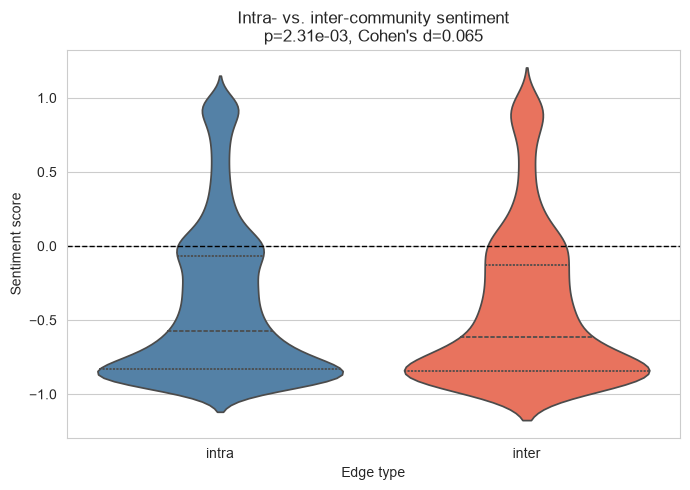

In [10]:
# --- Violin plot: intra vs inter sentiment ---
fig, ax = plt.subplots(figsize=(7, 5))

plot_data = pd.DataFrame({
    'sentiment': np.concatenate([intra, inter]),
    'type': ['intra'] * len(intra) + ['inter'] * len(inter)
})

sns.violinplot(data=plot_data, x='type', y='sentiment',
               palette={'intra': 'steelblue', 'inter': 'tomato'},
               inner='quartile', ax=ax)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Edge type')
ax.set_ylabel('Sentiment score')
ax.set_title(f'Intra- vs. inter-community sentiment\n'
             f'p={pval:.2e}, Cohen\'s d={cohens_d:.3f}')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p4_fig4_intra_inter_violin.png', dpi=150, bbox_inches='tight')
plt.show()

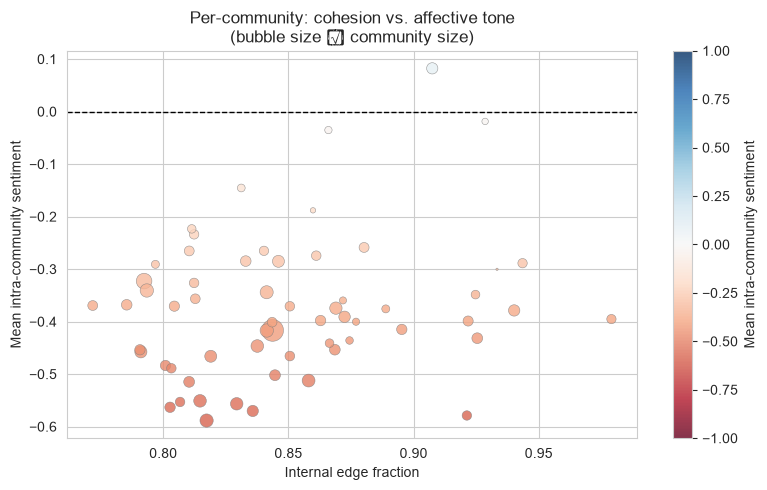

In [11]:
# --- Per-community: mean intra sentiment vs. fraction of internal edges ---
com_stats = defaultdict(lambda: {'intra_s': [], 'internal': 0, 'external': 0, 'size': 0})

# Community sizes
for n, c in node2com.items():
    com_stats[c]['size'] += 1

for u, v, d in G.edges(data=True):
    s = d.get('sentiment_roberta', np.nan)
    cu, cv = node2com.get(u), node2com.get(v)
    if cu is None or cv is None:
        continue
    if cu == cv:
        com_stats[cu]['intra_s'].append(s if not np.isnan(s) else 0)
        com_stats[cu]['internal'] += 1
    else:
        com_stats[cu]['external'] += 1
        com_stats[cv]['external'] += 1

com_df = pd.DataFrame([
    {
        'community': c,
        'size': v['size'],
        'mean_intra_sent': np.mean(v['intra_s']) if v['intra_s'] else np.nan,
        'int_frac': v['internal'] / (v['internal'] + v['external'] / 2 + 1e-9)
    }
    for c, v in com_stats.items()
]).dropna()

com_df = com_df[com_df['size'] >= 5]  # ignore micro-communities

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(com_df['int_frac'], com_df['mean_intra_sent'],
                s=com_df['size'] / 3, c=com_df['mean_intra_sent'],
                cmap='RdBu', vmin=-1, vmax=1, alpha=0.8, edgecolors='grey', linewidths=0.4)
plt.colorbar(sc, ax=ax, label='Mean intra-community sentiment')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Internal edge fraction')
ax.set_ylabel('Mean intra-community sentiment')
ax.set_title('Per-community: cohesion vs. affective tone\n(bubble size ∝ community size)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p4_fig5_community_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading:** the intra/inter gap is statistically significant (Mann-Whitney p = 0.002) but practically negligible — Cohen's d = 0.065 sits well below the conventional "small effect" threshold of 0.2. Community boundaries are not sentiment boundaries: hostility is spread almost uniformly inside and across clusters. This is evidence *against* a classic echo-chamber reading, where hostility would concentrate either strictly within tribes or sharply at their edges.

## 4. Affective homophily

We treat `sent_undirected` as a continuous node attribute and compute the **numeric assortativity coefficient** (Pearson correlation of the attribute over the two endpoints of each edge).  
A positive value means nodes with similar sentiment scores preferentially connect — affective homophily.

In [12]:
# Attach node_sentiment as a node attribute
nx.set_node_attributes(G, node_sent_undirected, 'node_sentiment')

# Remove nodes with NaN sentiment for the assortativity computation
G_sent = G.subgraph([n for n in G.nodes() if not np.isnan(G.nodes[n].get('node_sentiment', np.nan))]).copy()

global_assort = nx.numeric_assortativity_coefficient(G_sent, 'node_sentiment')
print(f'Global affective assortativity (Pearson r): {global_assort:.4f}')

# Interpretation
if global_assort > 0.1:
    print('→ Positive homophily: hostile nodes tend to connect to other hostile nodes.')
elif global_assort < -0.1:
    print('→ Negative homophily (heterophily): hostile and positive nodes tend to connect.')
else:
    print('→ Near-zero assortativity: no strong sentiment sorting at the global level.')

Global affective assortativity (Pearson r): 0.2790
→ Positive homophily: hostile nodes tend to connect to other hostile nodes.


In [13]:
# --- Per-community assortativity ---
# Group nodes by community; for each community compute assortativity on the induced subgraph
from collections import defaultdict

com2nodes = defaultdict(list)
for n, c in node2com.items():
    if n in G_sent:
        com2nodes[c].append(n)

com_assort = {}
for c, members in com2nodes.items():
    if len(members) < 10:
        continue
    sub = G_sent.subgraph(members)
    if sub.number_of_edges() < 5:
        continue
    try:
        r = nx.numeric_assortativity_coefficient(sub, 'node_sentiment')
        com_assort[c] = {'assort': r, 'size': len(members)}
    except Exception:
        pass

assort_df = pd.DataFrame(com_assort).T.sort_values('assort')
print(f'Communities analysed: {len(assort_df)}')
print(f'Mean per-community assortativity: {assort_df["assort"].mean():.4f}')
print(f'Positive (homophilic): {(assort_df["assort"] > 0).sum()}')
print(f'Negative (heterophilic): {(assort_df["assort"] < 0).sum()}')
print()
print('Most homophilic communities (top 5):')
print(assort_df.tail(5).round(3))
print('\nMost heterophilic communities (bottom 5):')
print(assort_df.head(5).round(3))

Communities analysed: 59
Mean per-community assortativity: 0.2075
Positive (homophilic): 59
Negative (heterophilic): 0

Most homophilic communities (top 5):
    assort   size
44   0.424  137.0
33   0.441  152.0
38   0.441  143.0
6    0.445  257.0
31   0.483  155.0

Most heterophilic communities (bottom 5):
    assort   size
50   0.039  101.0
43   0.043  140.0
25   0.079  171.0
24   0.099  171.0
18   0.100  185.0


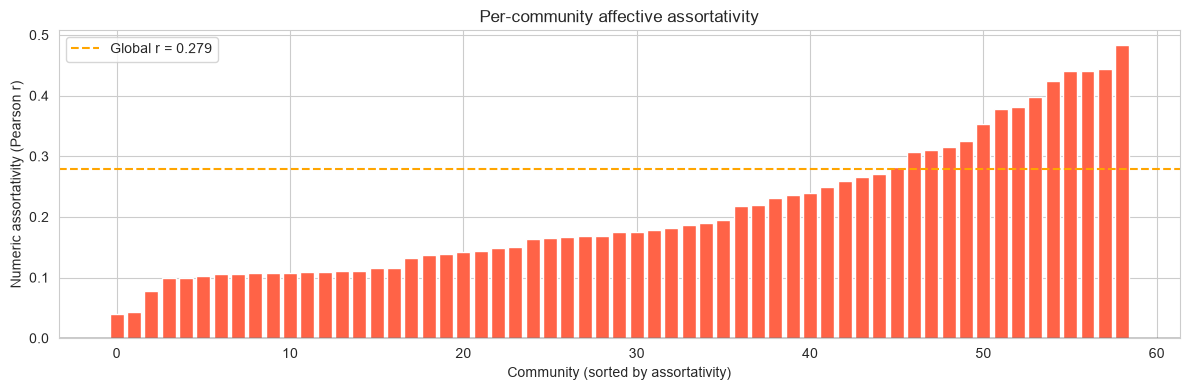

In [14]:
# --- Bar chart of per-community assortativity ---
fig, ax = plt.subplots(figsize=(12, 4))

colors = ['tomato' if v > 0 else 'steelblue' for v in assort_df['assort']]
ax.bar(range(len(assort_df)), assort_df['assort'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(global_assort, color='orange', linewidth=1.5, linestyle='--',
           label=f'Global r = {global_assort:.3f}')
ax.set_xlabel('Community (sorted by assortativity)')
ax.set_ylabel('Numeric assortativity (Pearson r)')
ax.set_title('Per-community affective assortativity')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p4_fig6_per_community_assortativity.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading:** this is the most robust pattern in the whole analysis: hostile accounts systematically connect to other hostile accounts (global r = 0.279), and the effect holds in every single community analysed (59 out of 59 positive, no exceptions). The network's real affective structure isn't "hostile communities vs. calm communities" — it's a continuum along which sentiment self-sorts edge by edge, largely independent of the modularity-based community boundaries from Section 3.

## 5. Outlier nodes

An **affective outlier** is a node that is structurally embedded in its community (i.e., most of its edges are internal) but whose sentiment score deviates strongly from the community mean.

These are interesting because they may represent:
- **Moderators** — structurally central but unusually positive
- **Infiltrators / bots** — structurally integrated but pushing a different affective tone
- **Bridge personalities** — connecting hostile sub-groups with a softer approach

**Two corrections applied here:**
- *Minimum degree (`deg_raw >= K`).* For a degree-1 node, `internal_ratio` is trivially 0 or 1 -- a single edge can't demonstrate "embeddedness". Only nodes with enough interactions to have a real neighbourhood are considered.
- *Percentile rank instead of a symmetric z-score.* Community-mean sentiment sits close to the -1 floor of the scale, so a -2σ deviation is often below -1 and mathematically unreachable -- a plain z-score would silently find zero negative outliers regardless of the data. Ranking nodes within their own community sidesteps the floor effect.

In [15]:
# For each node compute:
#   internal_ratio   = fraction of edges that stay inside the same community
#   z_within_com     = z-score of node_sentiment within its community (kept for
#                      reference; biased near the sentiment floor, see below)
#   pct_within_com   = percentile rank of node_sentiment within its community (0-1);
#                      unaffected by the floor/ceiling of the sentiment scale

# Community mean and std of node sentiment
df['community'] = df['community'].astype(str)
com_mean = df.groupby('community')['sent_undirected'].mean().rename('com_mean_sent')
com_std  = df.groupby('community')['sent_undirected'].std().rename('com_std_sent')
df = df.join(com_mean, on='community').join(com_std, on='community')
df['z_within_com'] = (df['sent_undirected'] - df['com_mean_sent']) / (df['com_std_sent'] + 1e-9)
df['pct_within_com'] = df.groupby('community')['sent_undirected'].rank(pct=True)

# Internal edge ratio per node
internal_ratio = {}
for n in G.nodes():
    cn = node2com.get(n)
    if cn is None:
        continue
    nbrs = list(G.neighbors(n))
    if not nbrs:
        continue
    internal = sum(1 for nb in nbrs if node2com.get(nb) == cn)
    internal_ratio[n] = internal / len(nbrs)

df['internal_ratio'] = pd.Series(internal_ratio)

# Outlier definition: embedded (enough interactions + mostly internal) but affectively
# deviant relative to the rest of its community.
EMBED_THRESH = 0.6           # at least 60% of edges are internal
PCT_LO, PCT_HI = 0.10, 0.90  # bottom / top 10% within the community

outliers = df[
    (df['deg_raw'] >= K) &
    (df['internal_ratio'] >= EMBED_THRESH) &
    ((df['pct_within_com'] <= PCT_LO) | (df['pct_within_com'] >= PCT_HI))
].copy()

print(f'Affective outliers identified: {len(outliers)}  (deg_raw >= {K}, internal_ratio >= {EMBED_THRESH})')
print(f'  Positive deviants (top {int((1 - PCT_HI) * 100)}% within community): {(outliers["pct_within_com"] >= PCT_HI).sum()}')
print(f'  Negative deviants (bottom {int(PCT_LO * 100)}% within community):  {(outliers["pct_within_com"] <= PCT_LO).sum()}')

Affective outliers identified: 8  (deg_raw >= 5, internal_ratio >= 0.6)
  Positive deviants (top 9% within community): 6
  Negative deviants (bottom 10% within community):  2


In [16]:
# Top positive outliers (embedded, well-observed, unusually positive vs. their community)
top_positive_outliers = (
    outliers[outliers['pct_within_com'] >= PCT_HI]
    .sort_values('pct_within_com', ascending=False)
    .head(10)
    [['community', 'sent_undirected', 'com_mean_sent', 'pct_within_com',
      'internal_ratio', 'deg_raw', 'betweenness']]
)
print('Top positive outliers:')
print(top_positive_outliers.round(3))
print()

top_negative_outliers = (
    outliers[outliers['pct_within_com'] <= PCT_LO]
    .sort_values('pct_within_com')
    .head(10)
    [['community', 'sent_undirected', 'com_mean_sent', 'pct_within_com',
      'internal_ratio', 'deg_raw', 'betweenness']]
)
print('Top negative outliers:')
print(top_negative_outliers.round(3))

Top positive outliers:
                    community  sent_undirected  com_mean_sent  pct_within_com  \
steveio2                   36            0.425         -0.384           0.952   
funranium                   6            0.110         -0.510           0.942   
priboy                      4            0.086         -0.578           0.938   
forageknoxville.com         0            0.421         -0.417           0.932   
spewey                      0            0.293         -0.417           0.914   
corwin88                    0            0.253         -0.417           0.909   

                     internal_ratio  deg_raw  betweenness  
steveio2                      0.667        6        0.002  
funranium                     1.000        5        0.000  
priboy                        0.800        5        0.001  
forageknoxville.com           1.000        5        0.000  
spewey                        1.000        5        0.000  
corwin88                      0.875        8     

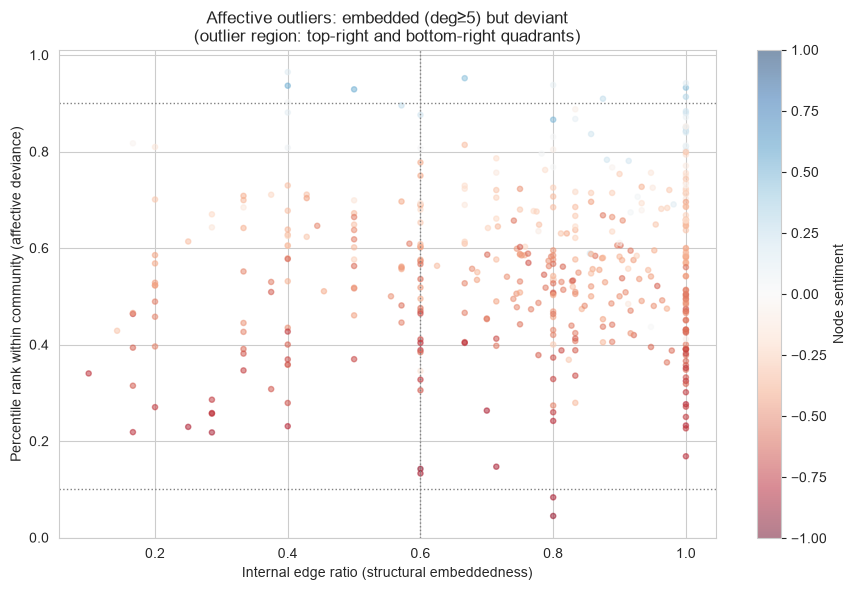

In [17]:
# --- Scatter: internal_ratio vs pct_within_com, coloured by sent_undirected ---
# Restricted to deg_raw >= K: below that, internal_ratio is a degenerate 0/1 signal.
plot_df = df[df['deg_raw'] >= K].dropna(subset=['internal_ratio', 'pct_within_com', 'sent_undirected'])

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    plot_df['internal_ratio'], plot_df['pct_within_com'],
    c=plot_df['sent_undirected'], cmap='RdBu', vmin=-1, vmax=1,
    s=14, alpha=0.5
)
plt.colorbar(sc, ax=ax, label='Node sentiment')

# Highlight outlier region
ax.axhline(PCT_HI, color='grey', linestyle=':', linewidth=1)
ax.axhline(PCT_LO, color='grey', linestyle=':', linewidth=1)
ax.axvline(EMBED_THRESH, color='grey', linestyle=':', linewidth=1)

ax.set_xlabel('Internal edge ratio (structural embeddedness)')
ax.set_ylabel('Percentile rank within community (affective deviance)')
ax.set_title(f'Affective outliers: embedded (deg≥{K}) but deviant\n'
             '(outlier region: top-right and bottom-right quadrants)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p4_fig7_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading:** under the corrected definition only 8 accounts qualify as genuine affective outliers (6 positive, 2 negative) — and the scarcity itself is informative: most well-observed, well-embedded accounts *follow* their community's tone (consistent with the homophily result above), so true affective deviants are rare. A caveat on how few they are: all eight sit just above the reliability threshold (`deg_raw` between 5 and 8), so each verdict rests on a handful of comments. The scarcity is a real finding, but the individual names should be read as illustrative rather than firmly established.

## 6. Summary

Collect all key numeric results in one place for easy copy-paste into the report.

**Overall picture.** The strongest, most consistent finding is affective homophily (r = 0.279 globally, positive in all 59 communities analysed) together with a stable instigator/target asymmetry (800 vs. 652, unchanged on the robust subset) — sentiment is structured by *who talks to whom*, not by raw structural prominence. Centrality only matters once "central" is disambiguated: traffic-based hubs (degree, betweenness, PageRank) show no relationship with sentiment once leaf noise is removed, while core-proximity measures (closeness, eigenvector) retain a modest negative association. Community boundaries, in turn, are not sentiment boundaries (d = 0.065) — this network does not fragment into hostile vs. calm tribes so much as it is uniformly hostile, with tone driven by direct ties rather than cluster membership.

The original research question — *"are structurally important nodes more negative/angry?"* — therefore has a qualified answer: **no for volume-based importance, weakly yes for core-proximity**. But the more interesting and better-supported story in this dataset is homophily: hostility spreads along direct ties, not through structural centrality.

In [18]:
print('=' * 60)
print('PART 4 — SUMMARY OF KEY RESULTS')
print('=' * 60)

print('\n--- 1. Node-level sentiment ---')
print(f'  Mean undirected node sentiment : {df["sent_undirected"].mean():.3f}')
print(f'  Mean in-sentiment (targets)    : {df["sent_in"].dropna().mean():.3f}')
print(f'  Mean out-sentiment (instigators): {df["sent_out"].dropna().mean():.3f}')
targets_n = (df_dir['role'] == 'target').sum() if 'df_dir' in dir() else 'N/A'
instig_n  = (df_dir['role'] == 'instigator').sum() if 'df_dir' in dir() else 'N/A'
print(f'  Targets:     {targets_n}  |  Instigators: {instig_n}')
print(f'  Robust subset (deg_raw >= {K}): {len(df_robust):,} / {len(df):,} nodes')

print('\n--- 2. Centrality–sentiment correlation (Spearman, sent_undirected) ---')
for subset_label in ['all', f'robust (deg>={K})']:
    print(f'  [{subset_label}]')
    sub = corr_df[(corr_df['sentiment'] == 'sent_undirected') & (corr_df['subset'] == subset_label)]
    for _, row in sub.iterrows():
        sig = '*' if row['significant'] else ''
        print(f'    {row["centrality"]:15s} ρ = {row["spearman_rho"]:+.4f}  p = {row["p_value"]:.3e} {sig}')

print('\n--- 3. Intra vs. inter community sentiment ---')
print(f'  Intra mean: {intra.mean():.3f}   Inter mean: {inter.mean():.3f}')
print(f'  Mann-Whitney p = {pval:.3e}   Cohen\'s d = {cohens_d:.3f}')

print('\n--- 4. Affective homophily ---')
print(f'  Global numeric assortativity: r = {global_assort:.4f}')
print(f'  Mean per-community assort.  : r = {assort_df["assort"].mean():.4f}')

print('\n--- 5. Affective outliers ---')
print(f'  Total outliers (deg≥{K}, embed≥{EMBED_THRESH}, pct≤{PCT_LO} or ≥{PCT_HI}): {len(outliers)}')
print(f'  Positive deviants: {(outliers["pct_within_com"] >= PCT_HI).sum()}')
print(f'  Negative deviants: {(outliers["pct_within_com"] <= PCT_LO).sum()}')
print('=' * 60)

PART 4 — SUMMARY OF KEY RESULTS

--- 1. Node-level sentiment ---
  Mean undirected node sentiment : -0.387
  Mean in-sentiment (targets)    : -0.327
  Mean out-sentiment (instigators): -0.394
  Targets:     652  |  Instigators: 800
  Robust subset (deg_raw >= 5): 421 / 10,595 nodes

--- 2. Centrality–sentiment correlation (Spearman, sent_undirected) ---
  [all]
    degree          ρ = +0.0828  p = 1.371e-17 *
    betweenness     ρ = +0.0752  p = 9.264e-15 *
    closeness       ρ = -0.0828  p = 1.365e-17 *
    eigenvector     ρ = -0.0764  p = 3.397e-15 *
    pagerank        ρ = +0.1138  p = 7.146e-32 *
  [robust (deg>=5)]
    degree          ρ = +0.0050  p = 9.182e-01 
    betweenness     ρ = -0.0437  p = 3.710e-01 
    closeness       ρ = -0.1699  p = 4.623e-04 *
    eigenvector     ρ = -0.1286  p = 8.223e-03 *
    pagerank        ρ = +0.0513  p = 2.937e-01 

--- 3. Intra vs. inter community sentiment ---
  Intra mean: -0.394   Inter mean: -0.428
  Mann-Whitney p = 2.306e-03   Cohen's 

In [19]:
# --- Persist enriched DataFrame for further use ---
df.to_csv('private/p4_node_sentiment_centrality.csv')
print('Saved: private/p4_node_sentiment_centrality.csv')

# Attach all new node attributes to the GCC and save
for col in ['sent_undirected', 'sent_in', 'sent_out', 'z_within_com', 'pct_within_com',
            'internal_ratio', 'deg_raw']:
    nx.set_node_attributes(G, df[col].dropna().to_dict(), col)

nx.write_gexf(G, 'private/dataset_part4_open_question.gexf')
print('Saved: private/dataset_part4_open_question.gexf')

Saved: private/p4_node_sentiment_centrality.csv


Saved: private/dataset_part4_open_question.gexf
